In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

**Load Dataset**

In [11]:
df=pd.read_csv("Superstore.csv")

In [15]:
print(df.head())

   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2017-152156  2017-11-08  2017-11-11    Second Class    CG-12520   
1       2  CA-2017-152156  2017-11-08  2017-11-11    Second Class    CG-12520   
2       3  CA-2017-138688  2017-06-12  2017-06-16    Second Class    DV-13045   
3       4  US-2016-108966  2016-10-11  2016-10-18  Standard Class    SO-20335   
4       5  US-2016-108966  2016-10-11  2016-10-18  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category  \
0     42420.0   Sout

**Data Exploration**

In [16]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9983 non-null   float64
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [17]:
print(df.describe())

            Row ID   Postal Code         Sales     Quantity     Discount  \
count  9994.000000   9983.000000   9994.000000  9994.000000  9994.000000   
mean   4997.500000  55245.233297    229.858001     3.789574     0.156203   
std    2885.163629  32038.715955    623.245101     2.225110     0.206452   
min       1.000000   1040.000000      0.444000     1.000000     0.000000   
25%    2499.250000  23223.000000     17.280000     2.000000     0.000000   
50%    4997.500000  57103.000000     54.490000     3.000000     0.200000   
75%    7495.750000  90008.000000    209.940000     5.000000     0.200000   
max    9994.000000  99301.000000  22638.480000    14.000000     0.800000   

            Profit  
count  9994.000000  
mean     28.656896  
std     234.260108  
min   -6599.978000  
25%       1.728750  
50%       8.666500  
75%      29.364000  
max    8399.976000  


In [18]:
print(df.dtypes)

Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code      float64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object


In [20]:
print(df.columns)

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')


**Check missing values.**


In [24]:
print(df.isnull().sum())

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Quantity          0
Discount          0
Profit            0
dtype: int64


**Filling Missing Values**

In [25]:
df['Postal Code'].fillna(df['Postal Code'].mode()[0],inplace = True)

In [27]:
print(df.isnull().sum()) #cross check

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


**Data Cleaning**

** converting Order Date and Ship Date to DateTime**

In [34]:
df['Order Date']=pd.to_datetime(df['Order Date'])
df['Ship Date']=pd.to_datetime(df['Ship Date'])
print(df.dtypes)

Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code             float64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
Quantity                  int64
Discount                float64
Profit                  float64
dtype: object


**Create Month Column**

In [35]:
df['Month']=df['Order Date'].dt.month

In [36]:
print(df.head())

   Row ID        Order ID Order Date  Ship Date       Ship Mode Customer ID  \
0       1  CA-2017-152156 2017-11-08 2017-11-11    Second Class    CG-12520   
1       2  CA-2017-152156 2017-11-08 2017-11-11    Second Class    CG-12520   
2       3  CA-2017-138688 2017-06-12 2017-06-16    Second Class    DV-13045   
3       4  US-2016-108966 2016-10-11 2016-10-18  Standard Class    SO-20335   
4       5  US-2016-108966 2016-10-11 2016-10-18  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ... Region  \
0      Claire Gute   Consumer  United States        Henderson  ...  South   
1      Claire Gute   Consumer  United States        Henderson  ...  South   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   West   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...  South   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...  South   

        Product ID         Category Sub-Category  \
0  FUR-BO-

**To the Duplicate Values**

In [42]:
print(df.duplicated().sum())

0


In [43]:
df.reset_index(drop=True,inplace=True)

**Total Sales**

In [44]:
print("Total Sales :",df['Sales'].sum())

Total Sales : 2297200.8603000003


**Total Profit**

In [45]:
print("Total Profit :",df['Profit'].sum())

Total Profit : 286397.0217


**Sales By Category**

In [48]:
Category_Sales = df.groupby('Category')['Sales'].sum()

In [49]:
print(Category_Sales)

Category
Furniture          741999.7953
Office Supplies    719047.0320
Technology         836154.0330
Name: Sales, dtype: float64


***Visualization***


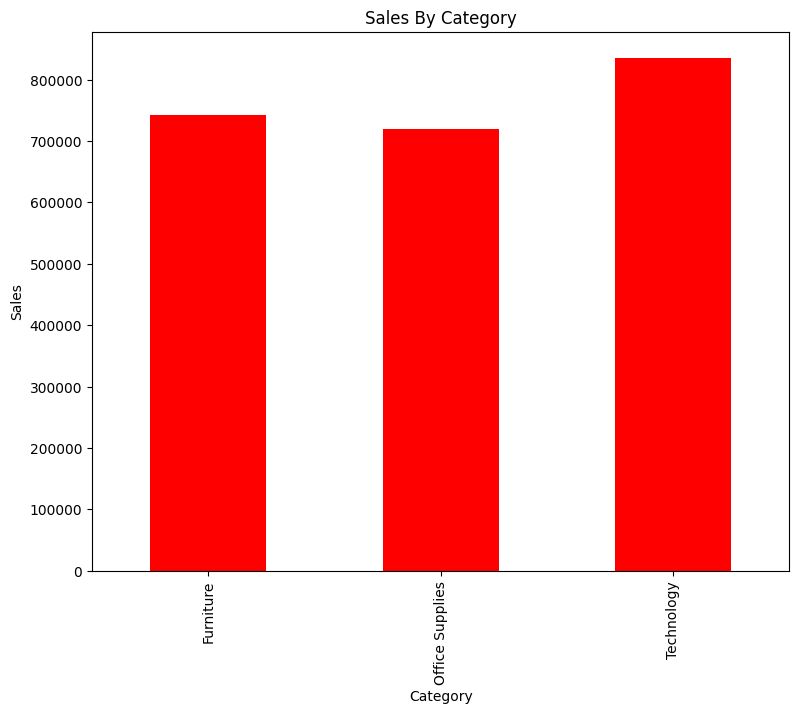

In [63]:
Category_Sales.plot(kind='bar',color = 'red',figsize=(9,7))
plt.xlabel('Category')
plt.ylabel('Sales')
plt.title('Sales By Category')
plt.show()

In [77]:
''' What This Chart Shows (Insight)'''
# Technology category generates the highest revenue.

# Office Supplies have steady sales.

# Furniture contributes moderate revenue but may have lower profit.

' What This Chart Shows (Insight)'

**Profit By Category**

In [61]:
Profit_Category=df.groupby('Category')['Profit'].sum()

In [62]:
print(Profit_Category)

Category
Furniture           18451.2728
Office Supplies    122490.8008
Technology         145454.9481
Name: Profit, dtype: float64


***Visualization***

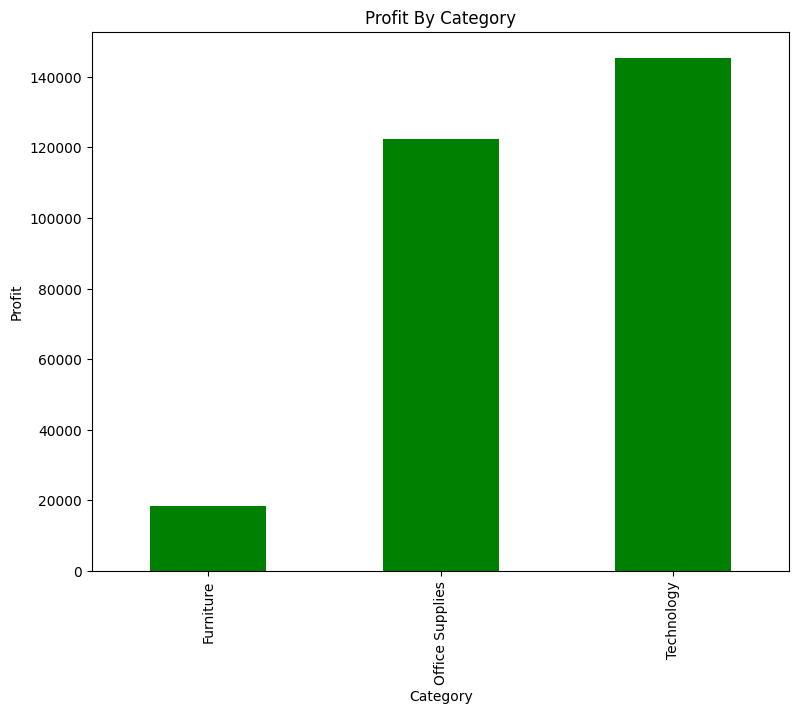

In [70]:
Profit_Category.plot(kind = 'bar',color = 'green',figsize=(9,7))
plt.xlabel('Category')
plt.ylabel('Profit')
plt.title('Profit By Category')
plt.show()

In [76]:
'''What This Chart Shows (Insight)'''
# Technology category generates highest profit

# Furniture may have lower profit margins

# Office Supplies has stable profit

'What This Chart Shows (Insight)'

**Sales by Region**

In [79]:
Region_Sales = df.groupby('Region')['Sales'].sum()

In [81]:
print(Region_Sales)

Region
Central    501239.8908
East       678781.2400
South      391721.9050
West       725457.8245
Name: Sales, dtype: float64


***Visualization***(Using Seaborn)

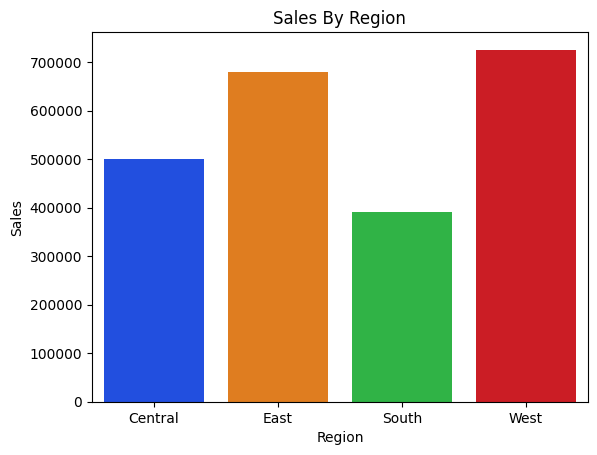

In [88]:
sns.barplot(x = Region_Sales.index,y=Region_Sales.values,palette='bright')
plt.xlabel('Region')
plt.ylabel('Sales')
plt.title('Sales By Region')
plt.show()



In [89]:
'''What This Chart Shows (Insight)'''
# The West region generates the highest sales
# The West region generates the highest sales
# The East and Central regions show moderate sales

'What This Chart Shows (Insight)'

**Top 10 Products by Sales**

In [92]:
Top_Products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending =False).head(10)

In [93]:
print(Top_Products)

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64


***Visualization***

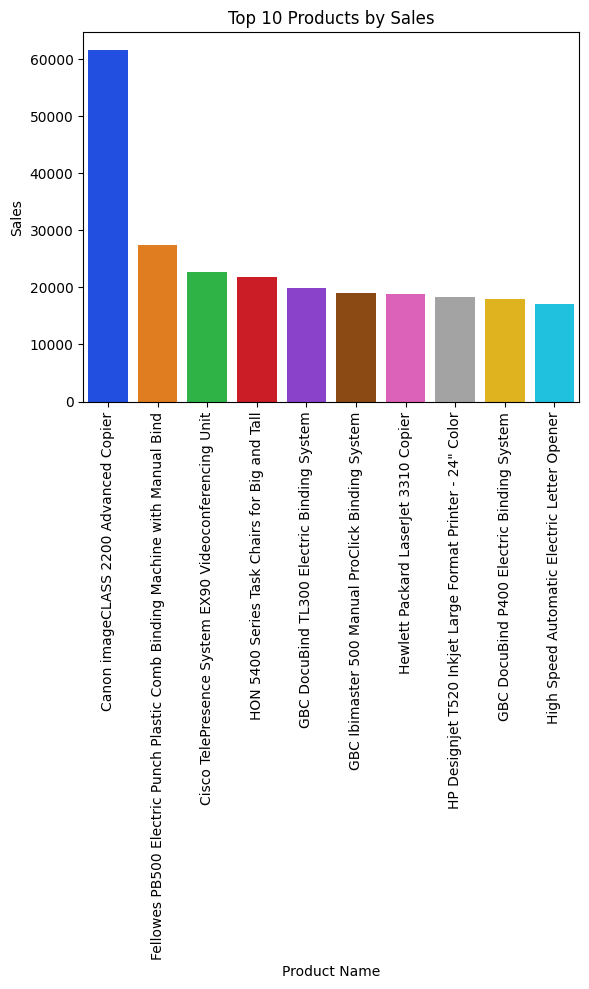

In [107]:
sns.barplot(x = Top_Products.index,y=Top_Products.values,palette='bright')
plt.xlabel('Product Name')
plt.ylabel('Sales')
plt.title('Top 10 Products by Sales')
plt.xticks(rotation=90)
plt.show()


**Monthly Sales Trend**

In [121]:
Monthly_Sales = df.groupby('Month')['Sales'].sum()
print(Monthly_Sales)

Month
1      94924.8356
2      59751.2514
3     205005.4888
4     137762.1286
5     155028.8117
6     152718.6793
7     147238.0970
8     159044.0630
9     307649.9457
10    200322.9847
11    352461.0710
12    325293.5035
Name: Sales, dtype: float64


***Visualization***

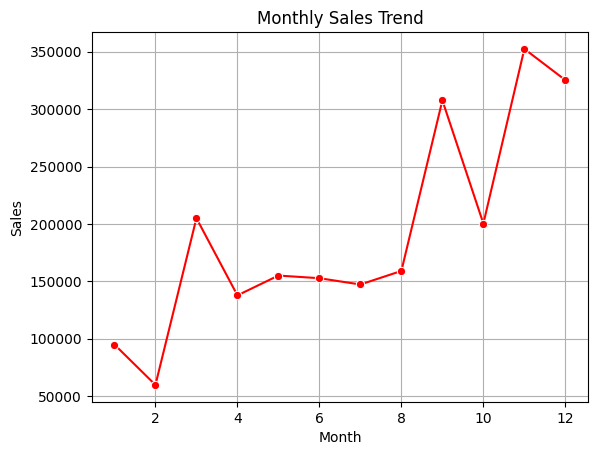

In [119]:
from matplotlib.markers import MarkerStyle
sns.lineplot(x=Monthly_Sales.index,y=Monthly_Sales.values,marker='o',color = "red")
plt.xlabel('Month')
plt.ylabel('Sales')
plt.title('Monthly Sales Trend')
plt.grid()
plt.show()

In [120]:
'''What This Chart Shows (Insight)'''
# Sales increase during the last months of the year, indicating strong seasonal demand.

'What This Chart Shows (Insight)'

**Profit vs Sales Analysis**

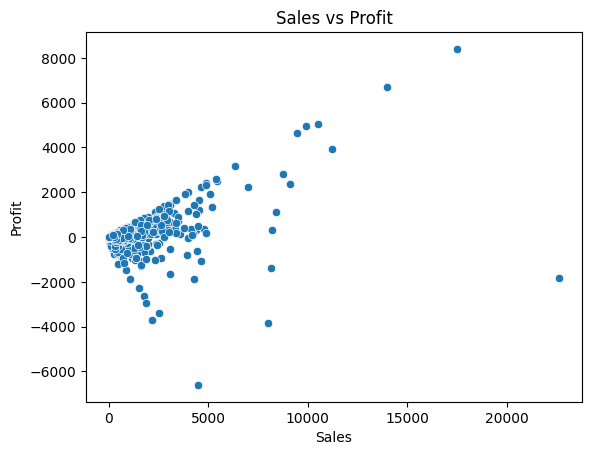

In [125]:
sns.scatterplot(x="Sales", y="Profit", data=df)

plt.title("Sales vs Profit")

plt.show()


** Region Profit Analysis**

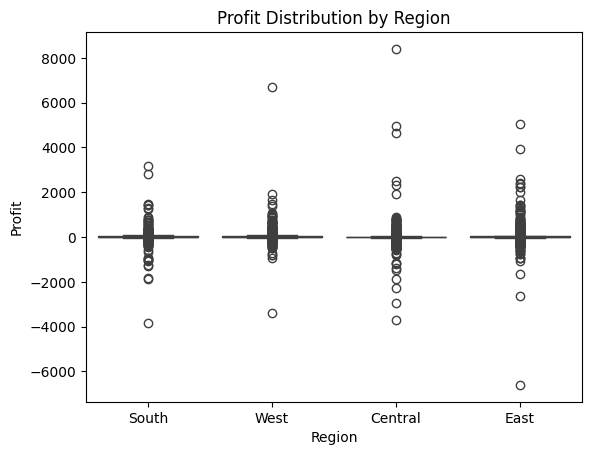

In [126]:
sns.boxplot(x="Region", y="Profit", data=df)

plt.title("Profit Distribution by Region")

plt.show()

**Final Business Insights**

In [127]:
# 1. Technology products drive the highest revenue.
# 2. West region performs best in sales.
# 3. Some products generate high sales but low profit.
# 4. Seasonal spikes occur in November and December.